# 09 · Electrical and thermal parts: cables, contactors, converters, heat exchanger, temperatures

The remaining components are smaller but carry two of the model's more interesting couplings: insulation that grows with bus voltage
*and* altitude (partial discharge), and machines whose power rating becomes a *temperature* limit, so short peaks (a hover, an
engine-out) may exceed the continuous rating. This notebook covers `cable.py`, `protection.py`, `converters.py` (the Tier 15
electrical layer, optional in the Halo), and `heat_exchanger.py`, `thermal.py` and `thermal/heat.py` (the Tier 19 thermal model, on
in the Halo reference).

**In this notebook**
1. `Cable`: conductor by current density, insulation by partial discharge at altitude; mass against voltage.
2. `ProtectionUnit`: contactors and fuses.
3. `Inverter` and `DcDcConverter`: the converter loss model.
4. `RamAirHeatExchanger`: heat rejection, pumping power, cooling drag, hover fans, rating.
5. `LumpedThermalModel`: one temperature per component; the exact interval solution; why constraining interval ends is enough.
6. `thermal_parameters`: how a power rating becomes a temperature limit; how long a machine can be overloaded.
7. Where these appear in the Halo.

**Run time:** a few seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace
from aircraft_closure.powertrain.components.cable import Cable, PartialDischargeModel, aluminium_conductor, copper_conductor, pressure_ratio
from aircraft_closure.powertrain.components.protection import ProtectionUnit
from aircraft_closure.powertrain.components.converters import Inverter, DcDcConverter, ConverterLossModel
from aircraft_closure.powertrain.components.heat_exchanger import RamAirHeatExchanger
from aircraft_closure.powertrain.components.thermal import LumpedThermalModel

## 1. `Cable`

A DC feeder of `count_conductors` round conductors (2 for a ± pair) of length $L$:

- conductor area $A = I_\text{max} / J$ (design current density: 3 A/mm² aluminium, 4 A/mm² copper);
- loop resistance $R = \rho_e L n / A$; loss $RI^2$ (for either current sign), drop $RI$;
- insulation wall $t = \text{softmax}(t_\text{min},\ t_\text{PD})$, where $t_\text{PD}$ makes the **partial-discharge inception
  voltage** at the design altitude equal to a safety factor × the peak voltage. Dakin's empirical form,
  $\mathrm{PDIV} = 163\,(t/\varepsilon_r)^{0.46}$ V (t in µm) at sea level, falls with pressure as $(p/p_0)^{0.5}$ (Paschen). It inverts
  in closed form, so no iteration is needed;
- mass = conductor + insulation annulus, + 20 % accessories.

In [2]:
cable = Cable(length_m=8.0, max_current_A=800.0, max_voltage_V=900.0, altitude_design_m=13000 * u.foot)
print(f"conductor {cable.area_conductor_m2() * 1e6:.0f} mm2, insulation {cable.thickness_insulation_m() * 1e3:.2f} mm, "
      f"resistance {cable.resistance_ohm() * 1e3:.2f} mOhm, mass {cable.get_mass():.1f} kg")
r = cable.evaluate(600.0)
print(f"at 600 A: loss {r.power_loss_W:.0f} W, drop {r.voltage_drop_V:.2f} V")
check("the insulation's PDIV at the design altitude is exactly 1.5 x the peak voltage (when PD sizes the wall)",
      abs(cable.voltage_inception_V() - 1.5 * 900.0) / (1.5 * 900.0) < 1e-2)

conductor 267 mm2, insulation 0.42 mm, resistance 2.04 mOhm, mass 14.6 kg
at 600 A: loss 734 W, drop 1.22 V
PASS  the insulation's PDIV at the design altitude is exactly 1.5 x the peak voltage (when PD sizes the wall)


Feeder mass against bus voltage, for a fixed 400 kW transfer: a higher voltage needs less conductor (less current) but more
insulation, and more still at altitude. This is the physics behind the bus-voltage enumeration in the Halo driver
(`enumerate_bus_voltage`):

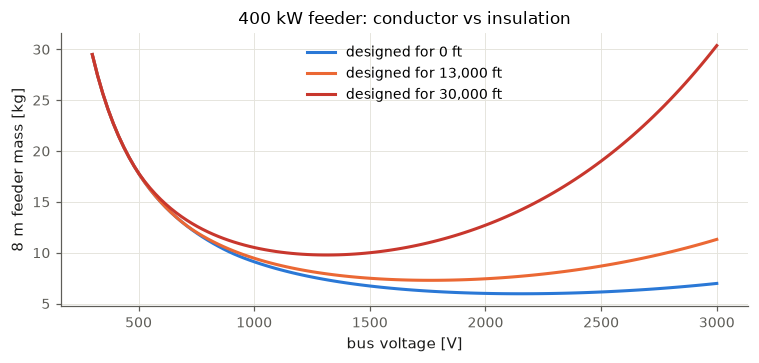

In [3]:
voltages_V = onp.linspace(300, 3000, 120)
fig, ax = plt.subplots(figsize=(7, 3.4))
for altitude_ft, color in ((0, blue), (13000, orange), (30000, red)):
    masses = [Cable(length_m=8.0, max_current_A=1.25 * 400e3 / v, max_voltage_V=v, altitude_design_m=altitude_ft * u.foot).get_mass()
              for v in voltages_V]
    ax.plot(voltages_V, masses, color=color, lw=2, label=f"designed for {altitude_ft:,} ft")
ax.set(xlabel="bus voltage [V]", ylabel="8 m feeder mass [kg]", title="400 kW feeder: conductor vs insulation")
ax.legend(); plt.tight_layout(); plt.show()

The cable's operating margins (`compatibility.py`) are current² ≤ rating² (smooth through zero current) and
1.5 × operating voltage ≤ PDIV *at the point's pressure*: a cable designed for 13,000 ft is checked at every flight point's altitude.

## 2. `ProtectionUnit`

Line contactors and fuses, one set per feeder: mass $= n_\text{poles}(0.2\text{ kg} + 1.3\text{ g/A} \times I_\text{max})$, loss from a rated
contact drop (0.15 V per pole at rated current), resistive. The Halo's redundancy uses one per battery string (`protection_string`)
and per bus tie.

In [4]:
contactor = ProtectionUnit(max_current_A=600.0)
print(f"mass {contactor.get_mass():.2f} kg, resistance {contactor.resistance_ohm() * 1e3:.3f} mOhm, "
      f"loss at 600 A {contactor.evaluate(600.0).power_loss_W:.0f} W")

mass 1.96 kg, resistance 0.500 mOhm, loss at 600 A 180 W


## 3. Converters

`ConverterLossModel` splits the rated loss $L_r = P_r(1 - \eta_r)/\eta_r$ into fixed, switching and conduction parts:

$$P_\text{loss} = L_r\Big[f_0 + f_s\frac{|P|}{P_r} + f_c\Big(\frac{P}{P_r}\Big)^2\Big(\frac{V_r}{V}\Big)^2\Big],\qquad f_0 = 1 - f_s - f_c$$

so efficiency is exactly $\eta_r$ at rated power and voltage, peaks at $|P|/P_r = \sqrt{f_0/f_c}$, and falls when the DC voltage sags (more
current for the same power). $|P|$ is smoothed as $\sqrt{P^2 + (\epsilon P_r)^2}$ so the model is differentiable through zero (a generator's
rectifier runs at negative power). The `Inverter` serves both the motor drive and the generator's active rectifier; the optional
`DcDcConverter` regulates the bus.

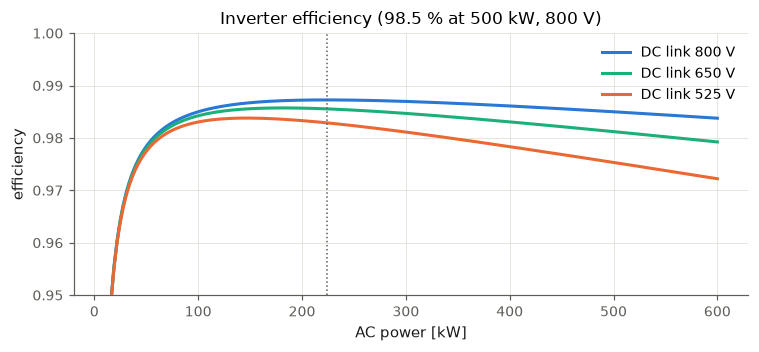

PASS  efficiency is exactly the rated 98.5 % at rated power and voltage (up to the |P| smoothing)
inverter mass 25.0 kg; DC-link limit 900 V (1,200 V devices x 0.75 cosmic-ray derating)


In [5]:
inverter = Inverter(power_rated_W=500e3)
powers = onp.linspace(10e3, 600e3, 200)
fig, ax = plt.subplots(figsize=(7, 3.3))
for voltage_V, color in ((800.0, blue), (650.0, aqua), (525.0, orange)):
    eta = [p / inverter.evaluate(p, voltage_V).power_dc_W for p in powers]
    ax.plot(powers / 1e3, eta, color=color, lw=2, label=f"DC link {voltage_V:.0f} V")
ax.axvline(500e3 * onp.sqrt(0.1 / 0.5) / 1e3, color=ink_muted, ls=":", lw=1)
ax.set(xlabel="AC power [kW]", ylabel="efficiency", ylim=(0.95, 1.0), title="Inverter efficiency (98.5 % at 500 kW, 800 V)")
ax.legend(); plt.tight_layout(); plt.show()
r = inverter.evaluate(500e3, 800.0)
check("efficiency is exactly the rated 98.5 % at rated power and voltage (up to the |P| smoothing)",
      abs(500e3 / r.power_dc_W - 0.985) < 1e-6)
print(f"inverter mass {inverter.get_mass():.1f} kg; DC-link limit {inverter.get_limits().max_voltage_V:.0f} V "
      f"(1,200 V devices x 0.75 cosmic-ray derating)")

## 4. `RamAirHeatExchanger`

A liquid-to-air exchanger rated `power_rated_W` at a 40 K coolant-to-air difference. At a point with heat $Q$ and ambient $T_a$
($\Delta T = T_c - T_a$):

- air mass flow $\dot m = Q / (\varepsilon c_p \Delta T)$; pressure loss $\Delta p = \Delta p_\text{ref}(\dot m/\dot m_\text{ref})^2 (\rho_\text{ref}/\rho)$;
- pumping power $P = \dot m\,\Delta p/\rho$;
- **airplane mode**: cooling drag $D = P/V$ (Meredith: the drag power is the flow work lost; heat-addition thrust not credited);
- **hover** (`fan=True`): no ram air, so fans supply $P/\eta_\text{fan}$ from the bus;
- required rating $Q\,\Delta T_\text{ref}/\Delta T$, constrained below the rating by the caller.

Pumping power grows as $Q^3/(\Delta T^3 Q_\text{rated}^2)$: a bigger exchanger is heavier but has much less drag, and a hot day
($\Delta T$ smaller) is expensive. That is why the Halo's hot-day hover sizes the exchanger:

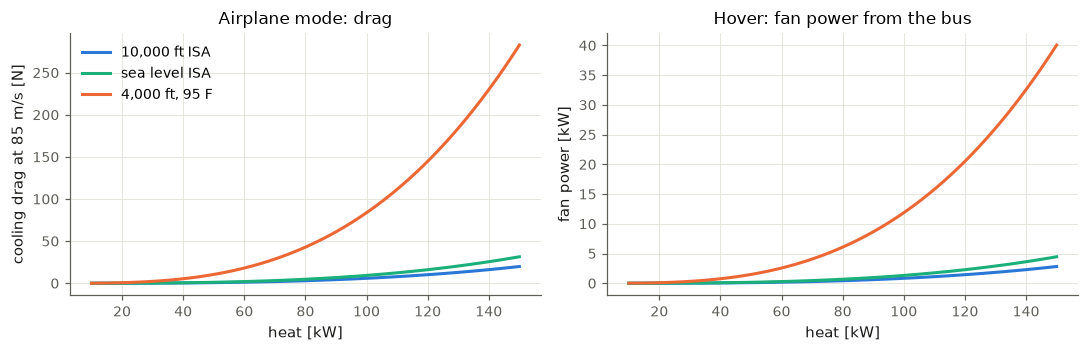

100 kW on the 95 F day: coolant-air difference 25.0 K -> needs a 160 kW-rated exchanger (rating is quoted at 40 K)


In [6]:
exchanger = RamAirHeatExchanger(power_rated_W=150e3)
heats = onp.linspace(10e3, 150e3, 100)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
for label, atmosphere, color in (("10,000 ft ISA", asb.Atmosphere(3048.0), blue), ("sea level ISA", asb.Atmosphere(0.0), aqua),
                                 ("4,000 ft, 95 F", asb.Atmosphere(1219.2, temperature_deviation=27.7), orange)):
    axes[0].plot(heats / 1e3, [exchanger.evaluate(q, atmosphere, velocity_m_s=85.0).drag_N for q in heats], color=color, lw=2, label=label)
    axes[1].plot(heats / 1e3, [exchanger.evaluate(q, atmosphere, fan=True).power_fan_W / 1e3 for q in heats], color=color, lw=2)
axes[0].set(xlabel="heat [kW]", ylabel="cooling drag at 85 m/s [N]", title="Airplane mode: drag")
axes[1].set(xlabel="heat [kW]", ylabel="fan power [kW]", title="Hover: fan power from the bus")
axes[0].legend(); plt.tight_layout(); plt.show()
hot = exchanger.evaluate(100e3, asb.Atmosphere(1219.2, temperature_deviation=27.7), fan=True)
print(f"100 kW on the 95 F day: coolant-air difference {hot.delta_temperature_C:.1f} K -> needs a "
      f"{hot.power_heat_equivalent_W / 1e3:.0f} kW-rated exchanger (rating is quoted at 40 K)")

## 5. `LumpedThermalModel`

One temperature per component, capacitance $C$ and resistance $R$ to a coolant at $T_c$: $C\dot T = Q - (T - T_c)/R$. For constant
loss over an interval the exact solution is

$$T(t) = T_\text{ss} + (T_0 - T_\text{ss})e^{-t/\tau},\qquad T_\text{ss} = T_c + QR,\qquad \tau = RC.$$

$T$ moves **monotonically** from $T_0$ toward $T_\text{ss}$, so the hottest moment of an interval is at one of its ends. Constraining the end
temperature of every interval therefore constrains the whole history: no collocation, no extra variables. The interval mean
(used for the heat passed to the coolant) is $T_\text{ss} + (T_0 - T_\text{ss})\,g$, $g = (\tau/t)(1 - e^{-t/\tau})$, the same algebra as
the battery's RC branches in tutorial 07.

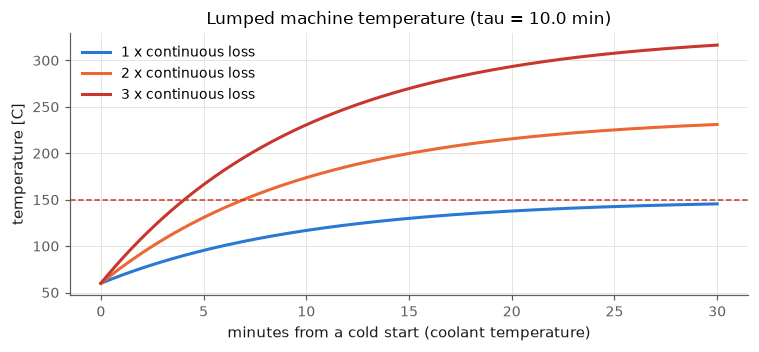

PASS  steady state at the continuous loss sits exactly on the limit


In [7]:
thermal = LumpedThermalModel(specific_heat_J_kg_K=500.0, temperature_max_C=150.0, temperature_coolant_C=60.0)
capacity_J_K, resistance_K_W = 500.0 * 80.0, 90.0 / 6000.0              # an 80 kg machine; 6 kW loss at its continuous rating
times = onp.linspace(0, 1800, 400)
fig, ax = plt.subplots(figsize=(7, 3.3))
for factor, color in ((1.0, blue), (2.0, orange), (3.0, red)):
    temps = [thermal.temperature_end_C(factor * 6000.0, t, capacity_J_K, resistance_K_W, 60.0) if t > 0 else 60.0 for t in times]
    ax.plot(times / 60, temps, color=color, lw=2, label=f"{factor:.0f} x continuous loss")
ax.axhline(150, color=red, ls="--", lw=1)
ax.set(xlabel="minutes from a cold start (coolant temperature)", ylabel="temperature [C]",
       title=f"Lumped machine temperature (tau = {capacity_J_K * resistance_K_W / 60:.1f} min)")
ax.legend(); plt.tight_layout(); plt.show()
check("steady state at the continuous loss sits exactly on the limit",
      abs(thermal.temperature_steady_C(6000.0, resistance_K_W) - 150.0) < 1e-9)

## 6. From power rating to temperature limit

`thermal/heat.py: thermal_parameters(component)` derives $C$ and $R$ from what a component already has:
$C = c \times$ mass, and $R = (T_\text{max} - T_c)/L_\text{cont}$ with $L_\text{cont}$ the loss at the continuous rating (machines: rated power at
the rated speed). So **the steady state at the continuous rating sits exactly on the temperature limit**, and the rating keeps its
meaning. With a thermal model on, `operating_margins` drops the machine's power margin and the flight point adds a temperature
margin instead (normalized by the allowed rise). Short peaks above the rating are then allowed, for as long as the thermal mass
absorbs them.

In [8]:
from aircraft_closure.thermal.heat import thermal_parameters
from aircraft_closure.powertrain.components.motor import Motor, rubber_machine, TorqueDensityMassModel
motor = rubber_machine(Motor, 200.0, 1200.0, torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5,
                       mass_model=TorqueDensityMassModel(), thermal_model=thermal)
p = thermal_parameters(motor)
print(f"motor: rated {motor.power_rated_W / 1e3:.0f} kW continuous, {motor.get_mass():.0f} kg, continuous loss {p.power_loss_continuous_W / 1e3:.2f} kW")
print(f"       C = {p.capacity_J_K / 1e3:.0f} kJ/K, R = {p.resistance_K_W * 1e3:.2f} K/kW, tau = {p.capacity_J_K * p.resistance_K_W / 60:.1f} min")

motor: rated 300 kW continuous, 200 kg, continuous loss 12.81 kW
       C = 100 kJ/K, R = 7.02 K/kW, tau = 11.7 min


How much torque can this motor deliver for a 60 s hover from a cold start, without exceeding 150 °C and within its peak-torque limit?
An Opti with the temperature margin as the only thermal constraint:

In [9]:
from aircraft_closure.core.margins import margin_below
opti = asb.Opti()
torque_Nm = opti.variable(init_guess=1500.0, scale=1000.0, lower_bound=0.0)
speed_rad_s = 200.0
state = motor.evaluate(speed_rad_s, torque_Nm, 750.0)
end_C = thermal.temperature_end_C(state.power_loss_W, 60.0, p.capacity_J_K, p.resistance_K_W, thermal.temperature_coolant_C)
margins = [margin_below("hover: motor temperature_C", end_C, 150.0), margin_below("hover: motor torque_Nm", torque_Nm, motor.max_torque_Nm)]
opti.subject_to([m.value >= 0 for m in margins])
opti.maximize(torque_Nm / 1000)
s = opti.solve(verbose=False)
print(f"60 s from cold: {s.value(torque_Nm):.0f} N m = {s.value(state.power_shaft_W) / motor.power_rated_W:.2f} x the continuous power "
      f"(end temperature {s.value(end_C):.1f} C)")
for m in margins:
    print(f"   margin {s.value(m.value):+.4f}  {m.label}")
check("a 60 s peak may exceed the continuous rating", s.value(state.power_shaft_W) > motor.power_rated_W)

60 s from cold: 3000 N m = 2.00 x the continuous power (end temperature 80.8 C)
   margin +0.4610  hover: motor temperature_C
   margin -0.0000  hover: motor torque_Nm
PASS  a 60 s peak may exceed the continuous rating


Here the peak-torque limit binds before temperature does. With a longer hover or a warmer start, temperature binds instead. In the
Halo the take-off hover starts from coolant temperature, and the failure hovers start from the thermal state at the end of the take-off
hover (the "thermal history").

`evaluate_point_thermal` (in `thermal/heat.py`) does this for every heat source of a flight point: it takes the `HeatLoad`s (named loss
sources × active counts), computes each thermal component's end and mean temperatures, passes the right heat to the exchanger (the
heat to the coolant, which is less than the loss while the thermal mass warms up), and returns the margins. Tutorial 15 shows it inside a
flight point.

## 7. In the Halo

In [10]:
import examples.halo_sizing as hs
a = hs.HaloAssumptions()
print("electrical_layer :", a.electrical_layer, " (inverters, cables, contactors between machines, battery and bus)")
print("thermal_model    :", a.thermal_model, " (heat exchanger rating is a design variable; machine and pack temperatures)")
print("redundancy       :", a.redundancy, " (string contactors and bus ties are ProtectionUnit + Cable)")
print("sources cooled elsewhere:", a.sources_excluded_heat_exchanger)

electrical_layer : False  (inverters, cables, contactors between machines, battery and bus)
thermal_model    : True  (heat exchanger rating is a design variable; machine and pack temperatures)
redundancy       : True  (string contactors and bus ties are ProtectionUnit + Cable)
sources cooled elsewhere: ('gearbox', 'generator_gearbox')


In the reference the electrical layer is off: the machines carry integrated figures (inverter mass included in their mass model) and
connect straight to the bus, a calibrated simplification (plan 023). The thermal model is on, and the redundancy hardware uses the
protection and cable components.

## Summary

- Cables: conductor by current density, insulation by a closed-form partial-discharge criterion that worsens with voltage and altitude.
- Converters: a rated-loss split into fixed, switching and conduction parts; efficiency depends on power and DC voltage.
- Heat exchanger: drag (or fan power) grows as the cube of heat over the temperature difference, so hot days size it.
- Lumped thermal model: exact interval solutions, monotone, so interval-end temperature margins suffice; the continuous rating maps onto
  the temperature limit, and short peaks may exceed it.

## Check yourself

<details><summary>1. Why is it enough to constrain the end temperature of each interval?</summary>

Within an interval at constant loss the temperature moves monotonically toward its steady state, so the maximum over the interval is at its start or its end, and the start is the previous interval's end, already constrained.
</details>

<details><summary>2. With the thermal model on, why can a motor's shaft power exceed its <code>power_rated_W</code> in a hover?</summary>

The rating becomes a continuous (thermal) rating; the binding physics is temperature. The power margin is dropped and replaced by a temperature margin at the end of the hover, which a short peak can satisfy thanks to the thermal mass.
</details>

In [11]:
check_summary()

4 of 4 checks passed
